# Deutsch-Jozsa Algorithm

Problem: Given a black box function $f: \{0,1\}^n \to \{0,1\}$, determine whether the function is constant, meaning it outputs the same value regardless of the input, or balanced, meaning it outputs 0 for half the inputs and 1 for the other half. The problem assumes that the function can only either be constant or balanced. 

A classical deterministic solution requires at worst $2^{n-1}+1$ queries to $f$ while the quantum algorithm takes advantage of quantum superposition and interference to solve the problem in 1 query to the oracle with complete certainty. If any qubit in the input register once measured is 1, the oracle is balanced, whereas if all input qubits measure to 0, it is constant. 

Unlike Deutsch's algorithm which had exactly 4 easily testable oracles, the Deutsch-Jozsa generalization still has only 2 constant functions, all 0 or all 1, but $\binom{2^n}{2^{n-1}}$ balanced functions. As such in this notebook, I tested the algorithm on 4 simple 3-bit functions, the 2 constant functions, the parity function returning the XOR sum of all input bits, and a first bit function returning the value of the first bit of the input. Both of these functions are balanced because there are an equal number of strings returning 0 and 1 respectively for each. Both of these functions have simple, linear structures that are easily exploitable for building oracles, which is why I used them for testing, but generic balanced functions with more complicated oracles would still be solvable with the same algorithm.

In [9]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from IPython.display import display

In [10]:
def constant_0(qc, n):
    pass
def constant_1(qc, n):
    qc.x(n)
def parity(qc,n): #bit sum mod 2 - cnot target on all input qubits
    for i in range(n):
        qc.cx(i, n)
def first_bit(qc, n): #output first bit - cnot target on first bit
    qc.cx(0,n) 

In [11]:
oracles = {'Constant 0 Oracle': constant_0, 'Constant 1 Oracle': constant_1, 'Parity Oracle': parity, 'First Bit Oracle': first_bit}

def make_deutsch_jozsa_circuit(oracle, n):
    assert oracle in oracles
    qc = QuantumCircuit(n+1, n)
    qc.x(n)
    for i in range(n+1):
        qc.h(i)
    #target prepared in |-> state for phase kickback
    oracles[oracle](qc,n)
    for i in range(n):
        qc.h(i)
    for i in range(n):
        qc.measure(i,i)
    return qc

Running Deutsch-Jozsa with particular oracles on 3 qubits with 1 ancilla qubit.
Deutsch-Jozsa Circuit for Constant 0 Oracle:


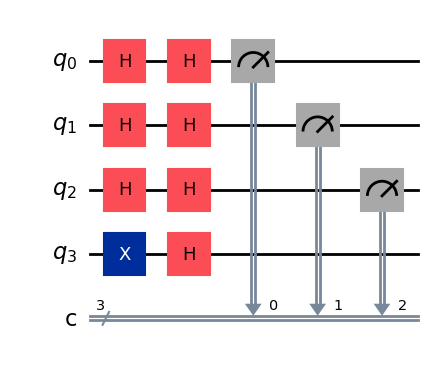

Constant

Deutsch-Jozsa Circuit for Constant 1 Oracle:


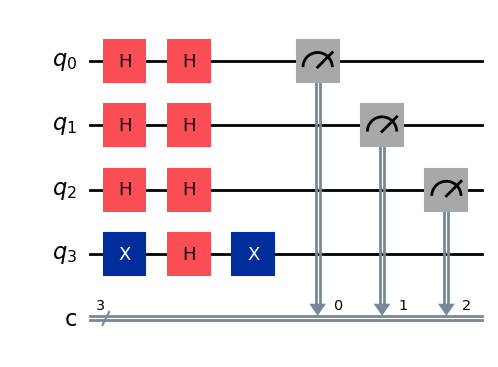

Constant

Deutsch-Jozsa Circuit for Parity Oracle:


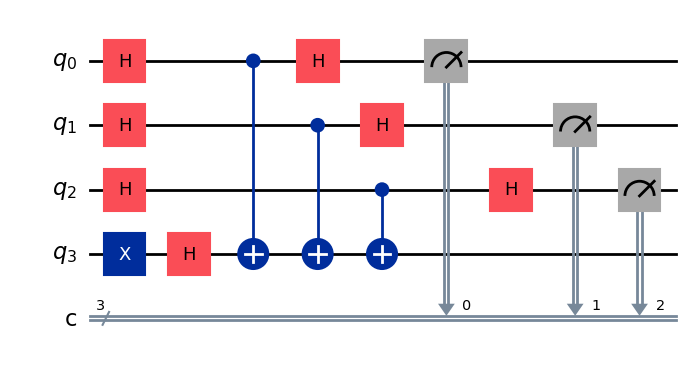

Balanced

Deutsch-Jozsa Circuit for First Bit Oracle:


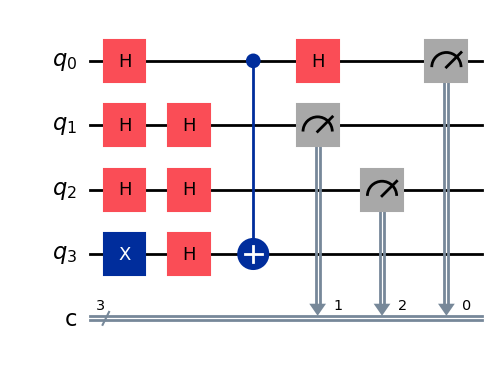

Balanced



In [12]:
n = 3
print(f'Running Deutsch-Jozsa with particular oracles on {n} qubits with 1 ancilla qubit.')
for oracle in oracles:
    circuit = make_deutsch_jozsa_circuit(oracle, n)
    print(f'Deutsch-Jozsa Circuit for {oracle}:')
    display(circuit.draw('mpl'))
    sampler = StatevectorSampler(default_shots=1000)
    result = sampler.run([circuit]).result()
    counts = result[0].data.c.get_counts()
    outcome = list(counts.keys())[0] #deterministic
    if '1' in outcome:
        print("Balanced")
    else:
        print("Constant")
    print()